Introduction to Data Science (Part B) 


--- Task 1 ---

Dataset used from: https://www.kaggle.com/datasets/datascientistanna/customers-dataset
The dataset was selected because it is a common real-world business dataset, which contains both categorical and continuous numerical variables with some missing values. 
The objective of this analysis is to discover the groups of customers with similar purchasing behaviours.

--- Task 2 ---

In [56]:
import pandas as pd
import matplotlib.pyplot as plt 
%matplotlib inline

customers = pd.read_csv('PartB_CustomersData.csv')
print("Columns:")
print(customers.columns)
print("Column and Row: ",customers.shape)
print("Data types of the values:")
print(customers.dtypes)
customers.head()

Columns:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income ($)',
       'Spending Score (1-100)', 'Profession', 'Work Experience',
       'Family Size'],
      dtype='object')
Column and Row:  (2000, 8)
Data types of the values:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income ($)          int64
Spending Score (1-100)     int64
Profession                object
Work Experience            int64
Family Size                int64
dtype: object


,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6


In [57]:
# Missing values
customers = customers.set_index("CustomerID")
customers.isnull().sum()

Gender                     0
Age                        0
Annual Income ($)          0
Spending Score (1-100)     0
Profession                35
Work Experience            0
Family Size                0
dtype: int64

In [58]:
customers[customers['Profession'].isnull()].sample(5)

,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
CustomerID,,,,,,,
1484,Female,19,147052,86,NaN,9,4
1010,Male,69,61637,67,NaN,0,5
602,Male,61,126370,20,NaN,11,4
1933,Female,23,59905,79,NaN,7,5
220,Female,59,76000,61,NaN,9,1


In [59]:
# Remove the rows that contain missing values
customers = customers.dropna()
customers.isnull().sum()

Gender                    0
Age                       0
Annual Income ($)         0
Spending Score (1-100)    0
Profession                0
Work Experience           0
Family Size               0
dtype: int64

The rows with missing values in the Profession column are removed as it is a categorical attribute, which cannot be replaced using numerical methods such as mean or median. It is removed to preserve data consistency and avoid inaccurate data assumptions.

In [60]:
# Show statistical calculation of the dataset
customers.describe()

,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size
count,1965.000000,1965.000000,1965.000000,1965.000000,1965.000000
mean,48.894656,110616.009669,51.078880,4.092621,3.757252
std,28.414889,45833.860195,27.977176,3.926459,1.968335
min,0.000000,0.000000,0.000000,0.000000,1.000000
25%,25.000000,74350.000000,28.000000,1.000000,2.000000
50%,48.000000,109759.000000,50.000000,3.000000,4.000000
75%,73.000000,149095.000000,75.000000,7.000000,5.000000
max,99.000000,189974.000000,100.000000,17.000000,9.000000


In [61]:
# Age Column Analysis
customers.loc[customers['Age'] < 18]

# The Age column was examined and it is observed to have unrealistic values based on the 
# statistical table. For instance, it has a value range of 0 - 99. 
# Records with ages below 18 were removed while older age values were retained as they may 
# still represent valid customers.

,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
CustomerID,,,,,,,
203,Female,16,60000,0,Engineer,6,8
211,Female,1,57000,93,Engineer,1,2
212,Female,0,22000,92,Artist,2,1
229,Male,0,33000,64,Marketing,1,1
230,Male,15,94000,30,Healthcare,7,2
...,...,...,...,...,...,...,...
1975,Female,14,153145,59,Healthcare,8,6
1980,Male,0,165321,93,Doctor,8,1
1981,Female,10,86925,76,Artist,7,2


In [62]:
# Remove customers with age < 18 (Outlier handling)
customers = customers[customers['Age'] >= 18]
customers.describe()

,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size
count,1638.000000,1638.000000,1638.000000,1638.000000,1638.000000
mean,56.972527,108864.531136,50.410867,4.012210,3.741758
std,23.884953,46338.542812,27.770225,3.903678,1.950794
min,18.000000,0.000000,0.000000,0.000000,1.000000
25%,36.000000,72459.750000,27.000000,1.000000,2.000000
50%,56.000000,106601.000000,49.500000,3.000000,4.000000
75%,78.000000,148273.500000,74.000000,7.000000,5.000000
max,99.000000,189974.000000,100.000000,17.000000,9.000000


Note that the minimum value of age is 18 after removing unrealistic data.

In [63]:
# Gender column Analysis
print(customers['Gender'].value_counts())
customers['Gender'].describe()

Gender
Female    974
Male      664
Name: count, dtype: int64


count       1638
unique         2
top       Female
freq         974
Name: Gender, dtype: object

Gender column has no data quality issue as it has valid 2 categories with no faulty values.

In [64]:
# Profession Column Analysis
print(customers['Profession'].value_counts())
customers['Profession'].describe()

Profession
Artist           514
Healthcare       281
Entertainment    197
Engineer         157
Doctor           127
Executive        126
Lawyer           118
Marketing         68
Homemaker         50
Name: count, dtype: int64


count       1638
unique         9
top       Artist
freq         514
Name: Profession, dtype: object

The Profession column has no data quality issue as it has valid categories and no faulty values.

In [65]:
# Check for Duplicate Rows
customers.duplicated().sum()

np.int64(0)

In [66]:
# Investigate customers with 0 values on different columns

# 1. Spending Score Column
customers[customers['Spending Score (1-100)'] == 0]

,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
CustomerID,,,,,,,
250,Female,89,65000,0,Engineer,0,5


This data can be valid, as the customer may be inactive or has no recent purchases.
Thus, it is retained.

In [67]:
# 2. Annual Income Column
customers[(customers['Annual Income ($)'] == 0)]

,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
CustomerID,,,,,,,
170,Male,32,0,63,Artist,2,2
247,Male,23,0,96,Doctor,1,3


This data is suspicious because they have zero annual income, but that has moderate to high spending score and with professions like Artist or Doctor. They are possibly missing data or having a data entry issue.
As such, these rows are removed from the dataset to avoid inconsistencies in customer purchasing behaviour.

In [68]:
# Remove customers with 0 annual income.
customers = customers[(customers['Annual Income ($)'] > 0)]
customers[(customers['Annual Income ($)'] == 0)]

,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
CustomerID,,,,,,,


In [69]:
# 3. Work Experience Column
print(customers[customers['Work Experience'] == 0]['Profession'].value_counts())
customers[customers['Work Experience'] == 0].sample(5)

Profession
Artist           111
Healthcare        67
Entertainment     50
Engineer          39
Lawyer            30
Executive         30
Doctor            25
Marketing         13
Homemaker          3
Name: count, dtype: int64


,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
CustomerID,,,,,,,
687,Female,58,74869,12,Healthcare,0,3
1226,Male,22,126543,45,Homemaker,0,3
1292,Male,94,69383,25,Entertainment,0,2
81,Male,57,52000,51,Healthcare,0,4
75,Male,59,89000,47,Artist,0,4


The Work Experience column contains a lot of zero values, which may be unrealistic in certain conditions, such as an older customer with a good annual income, while it remains believable in cases like young age customers, as it may be a fresh graduate or it was their first job. 
This may occur because of missing values or special reasons, such as the customer may have inherited wealth or be a business owner.
Thus, it should not be removed entirely, as they might be valid but only appear unusual and deleting them may heavily affect the dataset as they are huge (368 rows) in number. They are retained because there is insufficient evidence to determine whether they were incorrect entries or an alternative meaning of work experience.

--- Task 3 ---

After handling missing values, removing unsuitable records, checking duplicates and investigating zero values, the dataset became cleaner and more consistent for analysis. These preprocessing steps improved the overall data quality and reduced the risk of inaccurate clustering results.

In [70]:
# Scaling Data
from sklearn.preprocessing import StandardScaler

X = customers[['Annual Income ($)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [71]:
# Clustering
from sklearn.cluster import KMeans
k = 3
kmeans = KMeans(n_clusters=k).fit(X_scaled)


C:\Users\eliza\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


k = 3 is chosen as an initial concept for grouping customers based on the income level into High, Medium and Low, which may be associated with their spending score.

--- Task 4 ---

Text(0.5, 1.0, 'Customer Distribution by Income and Spending Score')

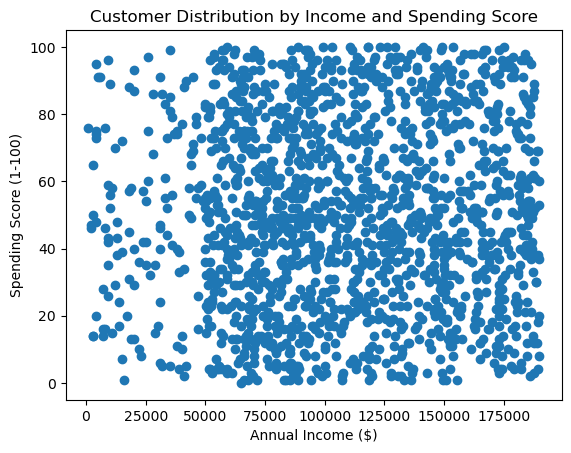

In [72]:
# Visualising the raw data 
# Scatter plot
plt.scatter(x= customers['Annual Income ($)'], y = customers['Spending Score (1-100)'])
plt.xlabel('Annual Income ($)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Distribution by Income and Spending Score')

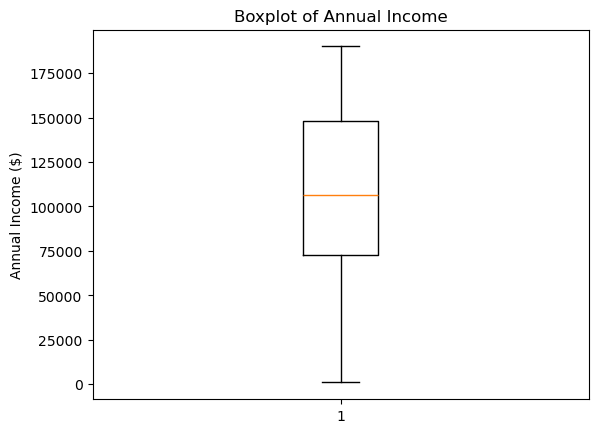

In [73]:
# Boxplot 
plt.boxplot(customers['Annual Income ($)'])
plt.title('Boxplot of Annual Income')
plt.ylabel('Annual Income ($)')
plt.show()


Alternative feature combinations were explored to identify more meaningful customer segmentation patterns.

Text(0.5, 1.0, 'Customer Distribution by Age and Spending Score')

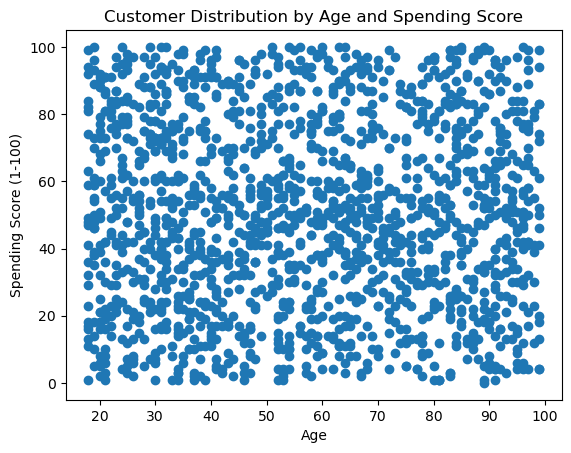

In [74]:
plt.scatter(x= customers['Age'], y = customers['Spending Score (1-100)'])
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Distribution by Age and Spending Score')

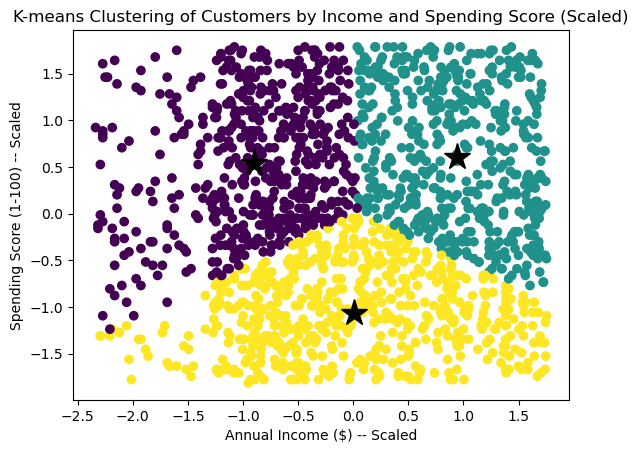

In [75]:
# Scaled Data Clustering Scatter Plot
plt.scatter(
     x=X_scaled[:,0],        # First column: scaled Income
     y=X_scaled[:,1],        # Second column: scaled Spending Score
     c=kmeans.labels_)
# Visualise the cluster centers (black stars)
plt.plot(
     kmeans.cluster_centers_[:,0],
     kmeans.cluster_centers_[:,1],
     'k*',
     markersize=20
)
plt.xlabel('Annual Income ($) -- Scaled')
plt.ylabel('Spending Score (1-100) -- Scaled')
plt.title('K-means Clustering of Customers by Income and Spending Score (Scaled)')
plt.show()

In [76]:
# Clusters coordinates
print(kmeans.cluster_centers_)

[[-0.90330316  0.54687492]
 [ 0.94488177  0.61077824]
 [ 0.00503138 -1.06656053]]


Data Scaling is necessary because K-means calculation involves continuous numerical features; features with a larger range (Annual Income 0-200000) would dominate the features with smaller scales (Spending Score 1-100) if not scaled. The income will have more influence on clustering than the Spending Score without scaling, even though they are equally significant for grouping customers' behavioural patterns.

--- Clustering Scatter Plot with Non-Scaled data

C:\Users\eliza\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


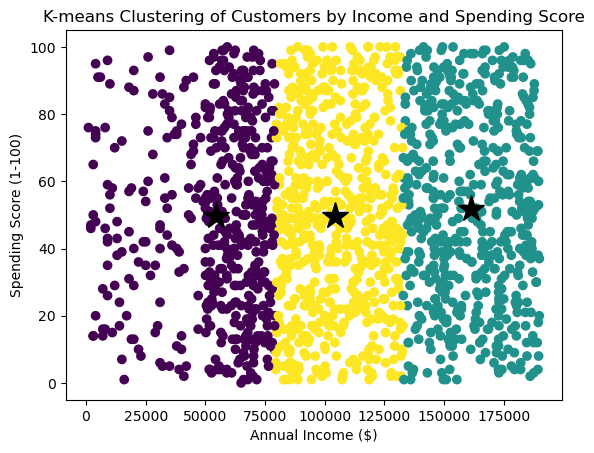

In [77]:
# Clustering Scatter Plot without Scaling data and k = 3
k = 3
kmeans2 = KMeans(n_clusters=k).fit(customers[['Annual Income ($)', 'Spending Score (1-100)']])
plt.scatter(
     x=customers['Annual Income ($)'],
     y=customers['Spending Score (1-100)'],       
     c=kmeans2.labels_)
# Visualise the cluster centers (black stars)
plt.plot(
     kmeans2.cluster_centers_[:,0],
     kmeans2.cluster_centers_[:,1],
     'k*',
     markersize=20
)
plt.xlabel('Annual Income ($)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-means Clustering of Customers by Income and Spending Score')
plt.show()

In [78]:
# Clusters coordinates
print(kmeans2.cluster_centers_)

[[5.45010453e+04 4.95699588e+01]
 [1.61441339e+05 5.17258065e+01]
 [1.04304606e+05 4.97635135e+01]]


C:\Users\eliza\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


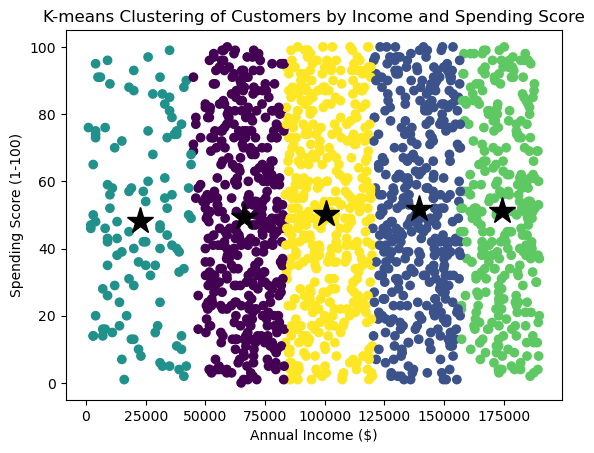

In [79]:
# Clustering Scatter Plot without Scaling data and k = 5
k = 5
kmeans2 = KMeans(n_clusters=k).fit(customers[['Annual Income ($)', 'Spending Score (1-100)']])
plt.scatter(
     x=customers['Annual Income ($)'],
     y=customers['Spending Score (1-100)'],       
     c=kmeans2.labels_)
# Visualise the cluster centers (black stars)
plt.plot(
     kmeans2.cluster_centers_[:,0],
     kmeans2.cluster_centers_[:,1],
     'k*',
     markersize=20
)
plt.xlabel('Annual Income ($)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-means Clustering of Customers by Income and Spending Score')
plt.show()

The clustering scatter plots for scaled data and non-scaled data appeared different because the raw data calculations were dominated by Annual Income. That is why clustering will be primarily based on income to assign clusters, and appear vertically segmented regardless of k value. While the scaled data clusters are based on a more equal relationship between Annual Income and Spending Score, which produced more meaningful clusters.

Summary:
The scatter plot does not show very clear or boundary-separated groups, as many data points appear evenly distributed and overlapping. Several k values were tested and compared. Then, k = 3 was retained as the best k because it provided a reasonable balance between the segmentation. A higher value of k will result in overly segmented, producing clusters that appear vertically grouped and a more imbalanced distance between data points and the centroid. 

--- Task 5 ---

This dataset is chosen because it satisfies the requirements of the assignment by containing some missing values and more than 2 numerical features suitable for clustering analysis. It is also one of the kinds of datasets commonly used for studying customers' purchasing patterns for business purposes.

The dataset contains continuous numerical features, such as Spending Score and Annual Income, which provide useful numerical information for identifying similarities in customer behaviour. Additionally, it includes contextual information, which is useful to support further analysis with other attributes on customer segmentation. 

Thus, k-means clustering is a suitable method for this because the objective is to group customers with similar characteristics based on numerical data. Since k-means works by identifying patterns through mathematical calculations of the data points, it is appropriate for forming customer segments from the dataset containing continuous numerical features.

--- Task 6 ---

Before implementing clustering on the data, I expected a clearer segmentation of data point patterns in the scatter plot, showing the strong relationship between the selected features. For example, I expected customers with high income and high spending to form one cluster, and high income/low spending another. However, the clustered scatter plot does not produce strongly separated clusters visually as the data points showed substantial overlap across the space. This made it more difficult to determine the optimal number of clusters through visual observation. 

This result also suggests that customer behaviour may not always be directly related to their income level. For instance, customers with similar income levels may demonstrate very different spending patterns, while some lower-income customers may still exhibit high spending behaviour. This indicates that customer behaviour is complex and may be influenced by other factors such as Family Size and Gender beyond income alone, which suggests that a simple two-dimensional segmentation may be insufficient.

Since the k-means clustering algorithm operates using mathematical distance-based calculations to categorise, the uniformly distributed data points may affect the quality of the clustering and reduce clarity.
Despite this limitation, k-means clustering was useful for identifying general customer segments of similar characteristics.

Referred to :
https://www.ibm.com/think/topics/k-means-clustering